

# Klasifikimi i të Dhënave HAM10000 me K-Means

Ky notebook përdor datasetin e filtruar HAM10000 për të kryer klasterizim duke përdorur algoritmin **K-Means** mbi metadata-n e pacientëve.

Procesi përfshin:
1️⃣ Ngarkimin dhe eksplorimin e datasetit.
2️⃣ Mbushjen e vlerave që mungojnë dhe One-Hot Encoding për variablat kategorike.
3️⃣ Ndarjen e të dhënave në grupe trajnimi (80%) dhe testimi (20%).
4️⃣ Standardizimin e veçorive.
5️⃣ Trajnimin e modelit K-Means me 2 klasterë (nv vs mel).
6️⃣ Përshtatjen dhe vlerësimin e klasterëve me etiketat e vërteta.
7️⃣ Ruajtjen e modelit dhe scaler-it për përdorim të mëvonshëm.

## Importimi i Bibliotekave

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    silhouette_score,
)

## Përcaktimi i Folderave

In [2]:
BASE_DIR = os.getcwd()
METADATA_PATH = os.path.join(BASE_DIR, "HAM10000_metadata_filtered.csv")

print("Base directory:", BASE_DIR)

Base directory: C:\Users\Admin\Documents\GitHub\DermaScan\ham_dataset


## Ngarkimi dhe Pastrimi i Metadata

In [3]:
df = pd.read_csv(METADATA_PATH)
print(f"Numri total i rreshtave në metadata: {len(df)}")

df["age"] = df["age"].fillna(df["age"].mean())
df.head()

Numri total i rreshtave në metadata: 2226


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000871,ISIC_0025964,mel,histo,40.0,female,chest
1,HAM_0000871,ISIC_0030623,mel,histo,40.0,female,chest
2,HAM_0000040,ISIC_0027190,mel,histo,80.0,male,upper extremity
3,HAM_0005678,ISIC_0031023,mel,histo,60.0,male,chest
4,HAM_0005678,ISIC_0028086,mel,histo,60.0,male,chest


## Përzgjedhja dhe Kodimi i Veçorive

In [4]:
feature_cols = ["age", "sex", "localization", "dx_type"]


X = pd.get_dummies(df[feature_cols], drop_first=True)

y = df["dx"].map({"nv": 0, "mel": 1}).values

print("Veçoritë pas One-Hot Encoding:")
print(X.columns.tolist())
X.head()

Veçoritë pas One-Hot Encoding:
['age', 'sex_male', 'sex_unknown', 'localization_acral', 'localization_back', 'localization_chest', 'localization_ear', 'localization_face', 'localization_foot', 'localization_genital', 'localization_hand', 'localization_lower extremity', 'localization_neck', 'localization_scalp', 'localization_trunk', 'localization_unknown', 'localization_upper extremity', 'dx_type_follow_up', 'dx_type_histo']


,age,sex_male,sex_unknown,localization_acral,localization_back,localization_chest,localization_ear,localization_face,localization_foot,localization_genital,localization_hand,localization_lower extremity,localization_neck,localization_scalp,localization_trunk,localization_unknown,localization_upper extremity,dx_type_follow_up,dx_type_histo
0,40.0,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
1,40.0,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
2,80.0,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True
3,60.0,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True
4,60.0,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True


## Ndarja e të Dhënave në Trajnim dhe Testim

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Madhësia e Train Set: {X_train.shape[0]}")
print(f"Madhësia e Test Set: {X_test.shape[0]}")

Madhësia e Train Set: 1780
Madhësia e Test Set: 446


## Standardizimi i Veçorive

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Trajnimi i Modelit K-Means

In [7]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
kmeans.fit(X_train_scaled)

print("Qendrat e klasterëve (Cluster Centers):")
print(kmeans.cluster_centers_)

Qendrat e klasterëve (Cluster Centers):
[[ 0.17810082  0.06291296 -0.0474579   0.01437382  0.1103225   0.09035209
   0.03815855  0.07966402  0.01029455 -0.06719131 -0.01154094 -0.05726334
   0.03510351  0.03807156 -0.20926425 -0.07819288  0.06644747 -0.60851034
   0.63748855]
 [-0.41556858 -0.14679692  0.1107351  -0.03353892 -0.25741917 -0.21082154
  -0.08903662 -0.18588272 -0.02402062  0.15677973  0.02692885  0.13361446
  -0.08190819 -0.08883363  0.48828326  0.18245005 -0.15504409  1.41985746
  -1.48747329]]


C:\Users\Admin\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=7.
  warnings.warn(


## Vlerësimi i Performancës së Klasterizimit

Rreshtimi më i mirë arrihet duke përmbysur klasat: True
Saktësia (Accuracy) në Test Set: 0.7623318385650224
Silhouette Score (Train): 0.2025

Classification Report:

                precision    recall  f1-score   support

    nv (Nevus)       1.00      0.52      0.69       223
mel (Melanoma)       0.68      1.00      0.81       223

      accuracy                           0.76       446
     macro avg       0.84      0.76      0.75       446
  weighted avg       0.84      0.76      0.75       446



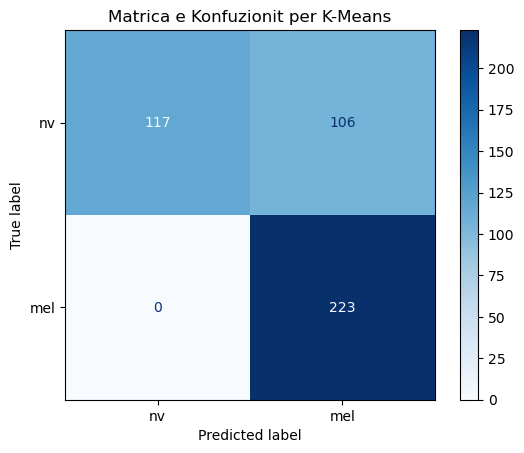

In [8]:
train_clusters = kmeans.labels_
acc_normal = accuracy_score(y_train, train_clusters)
acc_inverted = accuracy_score(y_train, 1 - train_clusters)

invert_map = acc_inverted > acc_normal
print(f"Rreshtimi më i mirë arrihet duke përmbysur klasat: {invert_map}")

test_clusters = kmeans.predict(X_test_scaled)
y_pred = 1 - test_clusters if invert_map else test_clusters

print("Saktësia (Accuracy) në Test Set:", accuracy_score(y_test, y_pred))
print(f"Silhouette Score (Train): {silhouette_score(X_train_scaled, train_clusters):.4f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['nv (Nevus)', 'mel (Melanoma)']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['nv', 'mel'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matrica e Konfuzionit per K-Means")
plt.show()

## Ruajtja e Modelit dhe Scaler-it

In [9]:
model_path = os.path.join(BASE_DIR, "kmeans_model.pkl")
scaler_path = os.path.join(BASE_DIR, "kmeans_scaler.pkl")
joblib.dump(kmeans, model_path)
joblib.dump(scaler, scaler_path)
print(f"Modeli K-Means u ruajt në: {model_path}")
print(f"Scaler u ruajt në: {scaler_path}")

Modeli K-Means u ruajt në: C:\Users\Admin\Documents\GitHub\DermaScan\ham_dataset\kmeans_model.pkl
Scaler u ruajt në: C:\Users\Admin\Documents\GitHub\DermaScan\ham_dataset\kmeans_scaler.pkl
